In [23]:
# ============================================
# CELL 1: IMPORTS AND CORE MODEL FUNCTION
# ============================================
# Run this cell first to load required libraries and define the model.

import numpy as np
import matplotlib.pyplot as plt

def terminal_no2_model(V, E_base, f_elec, Q_wind, Q_roof, C_out, C0, time_min):
    """
    Fixed-volume box model for NO₂ in a semi-enclosed bus terminal.
    
    GOVERNING EQUATION:
    V·dC/dt = E_base·(1 - f_elec) - (Q_wind + Q_roof)·(C - C_out)
    
    Parameters:
    -----------
    V : float
        Terminal volume (m³)
    E_base : float
        Base emission rate with all-diesel fleet (ppb·m³/hr)
    f_elec : float
        Fraction of fleet electrified (0 to 1)
    Q_wind : float
        Natural wind ventilation through open sides (m³/hr)
    Q_roof : float
        Rooftop exhaust fan ventilation rate (m³/hr)
    C_out : float
        Outdoor NO₂ concentration (ppb)
    C0 : float
        Initial indoor NO₂ concentration at simulation start (ppb)
    time_min : array
        Time points in minutes
    
    Returns:
    --------
    C : array
        NO₂ concentration over time (ppb)
    C_ss : float
        Steady-state (equilibrium) concentration (ppb)
    Q_total : float
        Total ventilation rate (m³/hr)
    """
    
    # Total ventilation = natural wind + mechanical rooftop exhaust
    Q_total = Q_wind + Q_roof
    
    # Effective emission rate after electrification
    E_eff = E_base * (1 - f_elec)
    
    # Steady-state concentration from mass balance (set dC/dt = 0)
    if Q_total > 0:
        C_ss = C_out + (E_eff / Q_total)
    else:
        C_ss = C0  # Degenerate case: no ventilation
    
    # Time in hours for exponential term
    time_hr = time_min / 60.0
    
    # Air exchange rate (1/hr)
    lambda_total = Q_total / V
    
    # Analytical solution to the differential equation
    C = C_ss - (C_ss - C0) * np.exp(-lambda_total * time_hr)
    
    return C, C_ss, Q_total

print("✓ Cell 1 complete: Libraries loaded and model function defined")
print("")
print("GOVERNING EQUATION: V·dC/dt = E_base·(1 - f_elec) - (Q_wind + Q_roof)·(C - C_out)")

✓ Cell 1 complete: Libraries loaded and model function defined

GOVERNING EQUATION: V·dC/dt = E_base·(1 - f_elec) - (Q_wind + Q_roof)·(C - C_out)


In [24]:
# ============================================
# CELL 2: FULLY INTERACTIVE INPUT INTERFACE
# ============================================
# Run this cell once. All changes to dropdowns will automatically update the summary.

import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np

# Fixed parameters (not adjustable by user)
C_out = 20.0           # Outdoor NO₂ (ppb) - urban background
C0 = 30.0              # Initial indoor NO₂ (ppb) - low overnight residual
emission_factor = 1.2  # g/hr NO₂ per idling diesel bus
simulation_hours = 16  # 6 AM to 10 PM

# Fixed engineering alternatives (BALANCED COMPARISON)
Q_roof_base = 0.0      # ACH (baseline and Alt A)
Q_roof_upgrade = 3.0   # ACH (Alt B)
f_elec_base = 0.0      # Baseline and Alt B (all diesel)
f_elec_altA = 0.5      # Alt A (50% electric fleet)

# Cost parameters
cost_per_electric_bus = 400000  # $400,000 per electric bus
cost_per_exhaust_m2 = 25        # $25 per m² for exhaust system

print("="*70)
print("BUS TERMINAL NO₂ MODEL - INTERACTIVE INPUTS")
print("="*70)
print("\nAdjust the dropdowns below. The parameter summary updates automatically.")
print("\nEngineering alternatives are fixed:")
print("  • Alt A: 50% Fleet Electrification (f_elec = 0.5)")
print("  • Alt B: Rooftop Exhaust Upgrade (+3 ACH added to baseline)")
print("")

# --------------------------------------------------
# CREATE WIDGETS
# --------------------------------------------------

# Terminal Volume
V_dropdown = widgets.Dropdown(
    options=[
        ('Small Terminal (5,000 m³)', 5000.0),
        ('Medium Terminal (10,000 m³)', 10000.0),
        ('Large Terminal (15,000 m³)', 15000.0),
        ('Custom...', 'custom')
    ],
    value=10000.0,
    description='Terminal Volume:',
    style={'description_width': '160px'}
)

V_custom = widgets.FloatText(
    value=10000.0,
    description='Custom V (m³):',
    style={'description_width': '160px'},
    layout={'visibility': 'hidden'}
)

def on_V_change(change):
    if change['new'] == 'custom':
        V_custom.layout.visibility = 'visible'
    else:
        V_custom.layout.visibility = 'hidden'
    update_summary()

V_dropdown.observe(on_V_change, names='value')
V_custom.observe(lambda change: update_summary(), names='value')

# Fleet Size (Total buses in fleet)
fleet_size_dropdown = widgets.Dropdown(
    options=[
        ('Small Fleet (20 buses)', 20.0),
        ('Medium Fleet (40 buses)', 40.0),
        ('Large Fleet (60 buses)', 60.0),
        ('Custom...', 'custom')
    ],
    value=40.0,
    description='Total Fleet Size:',
    style={'description_width': '160px'}
)

fleet_size_custom = widgets.FloatText(
    value=40.0,
    description='Custom (buses):',
    style={'description_width': '160px'},
    layout={'visibility': 'hidden'}
)

def on_fleet_change(change):
    if change['new'] == 'custom':
        fleet_size_custom.layout.visibility = 'visible'
    else:
        fleet_size_custom.layout.visibility = 'hidden'
    update_summary()

fleet_size_dropdown.observe(on_fleet_change, names='value')
fleet_size_custom.observe(lambda change: update_summary(), names='value')

# Buses per Hour (Peak)
buses_dropdown = widgets.Dropdown(
    options=[
        ('Off-Peak (10 buses/hr)', 10.0),
        ('Typical Peak (18 buses/hr)', 18.0),
        ('Heavy Peak (25 buses/hr)', 25.0),
        ('Custom...', 'custom')
    ],
    value=18.0,
    description='Peak Buses per Hour:',
    style={'description_width': '160px'}
)

buses_custom = widgets.FloatText(
    value=18.0,
    description='Custom (buses/hr):',
    style={'description_width': '160px'},
    layout={'visibility': 'hidden'}
)

def on_buses_change(change):
    if change['new'] == 'custom':
        buses_custom.layout.visibility = 'visible'
    else:
        buses_custom.layout.visibility = 'hidden'
    update_summary()

buses_dropdown.observe(on_buses_change, names='value')
buses_custom.observe(lambda change: update_summary(), names='value')

# Idle Time per Bus
idle_dropdown = widgets.Dropdown(
    options=[
        ('Quick Turnaround (3 min)', 3.0),
        ('Typical Layover (6 min)', 6.0),
        ('Extended Wait (9 min)', 9.0),
        ('Custom...', 'custom')
    ],
    value=6.0,
    description='Idle Time per Bus:',
    style={'description_width': '160px'}
)

idle_custom = widgets.FloatText(
    value=6.0,
    description='Custom (minutes):',
    style={'description_width': '160px'},
    layout={'visibility': 'hidden'}
)

def on_idle_change(change):
    if change['new'] == 'custom':
        idle_custom.layout.visibility = 'visible'
    else:
        idle_custom.layout.visibility = 'hidden'
    update_summary()

idle_dropdown.observe(on_idle_change, names='value')
idle_custom.observe(lambda change: update_summary(), names='value')

# Natural Wind Ventilation
Qwind_ach_dropdown = widgets.Dropdown(
    options=[
        ('Low Wind (0.5 ACH)', 0.5),
        ('Moderate Wind (1.0 ACH)', 1.0),
        ('High Wind (1.5 ACH)', 1.5),
        ('Custom...', 'custom')
    ],
    value=1.0,
    description='Natural Wind:',
    style={'description_width': '160px'}
)

Qwind_ach_custom = widgets.FloatText(
    value=1.0,
    description='Custom (ACH):',
    style={'description_width': '160px'},
    layout={'visibility': 'hidden'}
)

def on_Qwind_ach_change(change):
    if change['new'] == 'custom':
        Qwind_ach_custom.layout.visibility = 'visible'
    else:
        Qwind_ach_custom.layout.visibility = 'hidden'
    update_summary()

Qwind_ach_dropdown.observe(on_Qwind_ach_change, names='value')
Qwind_ach_custom.observe(lambda change: update_summary(), names='value')

# --------------------------------------------------
# OUTPUT AREA FOR SUMMARY
# --------------------------------------------------
output = widgets.Output()

# --------------------------------------------------
# UPDATE FUNCTION
# --------------------------------------------------
def update_summary():
    with output:
        clear_output(wait=True)
        
        # Get current values
        if V_dropdown.value == 'custom':
            V = V_custom.value
        else:
            V = V_dropdown.value
            
        if fleet_size_dropdown.value == 'custom':
            fleet_size = fleet_size_custom.value
        else:
            fleet_size = fleet_size_dropdown.value
            
        if buses_dropdown.value == 'custom':
            buses_per_hour = buses_custom.value
        else:
            buses_per_hour = buses_dropdown.value
            
        if idle_dropdown.value == 'custom':
            idle_time_min = idle_custom.value
        else:
            idle_time_min = idle_dropdown.value
            
        if Qwind_ach_dropdown.value == 'custom':
            Q_wind_ach = Qwind_ach_custom.value
        else:
            Q_wind_ach = Qwind_ach_dropdown.value
        
        # Calculate derived parameters
        Q_wind = Q_wind_ach * V
        Q_roof_base_m3hr = Q_roof_base * V
        Q_roof_upgrade_m3hr = Q_roof_upgrade * V
        terminal_area = V / 3.0  # Assume 3m ceiling height
        
        avg_buses_idling = buses_per_hour * (idle_time_min / 60.0)
        E_g_hr = avg_buses_idling * emission_factor
        E_base = E_g_hr * 1e6 / 1.88
        
        # Calculate costs
        electrified_buses = fleet_size * f_elec_altA
        electrification_cost = electrified_buses * cost_per_electric_bus
        exhaust_upgrade_cost = terminal_area * cost_per_exhaust_m2
        
        # Format cost strings
        if electrification_cost >= 1e6:
            elec_cost_str = f"${electrification_cost/1e6:.1f}M"
        else:
            elec_cost_str = f"${electrification_cost/1000:.0f}K"
            
        if exhaust_upgrade_cost >= 1e6:
            exhaust_cost_str = f"${exhaust_upgrade_cost/1e6:.1f}M"
        else:
            exhaust_cost_str = f"${exhaust_upgrade_cost/1000:.0f}K"
        
        # Calculate expected C_ss for preview
        if Q_wind > 0:
            C_ss_base_preview = C_out + (E_base / Q_wind)
            C_ss_elec_preview = C_out + (E_base * (1 - f_elec_altA) / Q_wind)
        else:
            C_ss_base_preview = C0
            C_ss_elec_preview = C0
            
        Q_total_vent = Q_wind + Q_roof_upgrade_m3hr
        if Q_total_vent > 0:
            C_ss_vent_preview = C_out + (E_base / Q_total_vent)
        else:
            C_ss_vent_preview = C0
        
        # Display summary
        print("="*70)
        print("MODEL PARAMETERS SUMMARY (Auto-Updates)")
        print("="*70)
        
        print("\nTERMINAL:")
        print(f"  Volume V: {V:.0f} m³")
        print(f"  Floor area: {terminal_area:.0f} m² (assuming 3m ceiling)")
        
        print("\nBUS FLEET:")
        print(f"  Total fleet size: {fleet_size:.0f} buses")
        print(f"  Peak buses per hour: {buses_per_hour:.0f}")
        print(f"  Idle time per bus: {idle_time_min:.0f} minutes")
        print(f"  Average buses idling: {avg_buses_idling:.1f}")
        print(f"  Emission factor: {emission_factor} g/hr per bus")
        print(f"  Base emission rate: {E_g_hr:.2f} g/hr = {E_base:.0f} ppb·m³/hr")
        
        print("\nNATURAL VENTILATION:")
        print(f"  Q_wind: {Q_wind_ach:.1f} ACH = {Q_wind:.0f} m³/hr")
        
        print("\nAMBIENT CONDITIONS (Fixed):")
        print(f"  C_out (outdoor NO₂): {C_out} ppb")
        print(f"  C0 (initial indoor NO₂): {C0} ppb")
        
        print("\n" + "="*70)
        print("THREE SCENARIOS FOR COMPARISON")
        print("="*70)
        
        print("\nBASELINE (Current Condition):")
        print(f"  f_elec = {f_elec_base} (0% electric)")
        print(f"  Q_roof = {Q_roof_base} ACH (0 m³/hr)")
        print(f"  Q_total = {Q_wind:.0f} m³/hr")
        baseline_flag = " ⚠️ EXCEEDS" if C_ss_base_preview > 100 else " ✓ Meets"
        print(f"  Expected C_ss ≈ {C_ss_base_preview:.0f} ppb{baseline_flag}")
        
        print("\nALTERNATIVE A: 50% Fleet Electrification")
        print(f"  f_elec = {f_elec_altA} ({electrified_buses:.0f} electric buses)")
        print(f"  Q_roof = {Q_roof_base} ACH (0 m³/hr)")
        print(f"  Q_total = {Q_wind:.0f} m³/hr")
        print(f"  Estimated cost: {elec_cost_str}")
        elec_flag = " ⚠️ EXCEEDS" if C_ss_elec_preview > 100 else " ✓ Meets"
        print(f"  Expected C_ss ≈ {C_ss_elec_preview:.0f} ppb{elec_flag}")
        
        print("\nALTERNATIVE B: Rooftop Exhaust Upgrade")
        print(f"  f_elec = {f_elec_base} (0% electric)")
        print(f"  Q_roof = {Q_roof_upgrade} ACH ({Q_roof_upgrade_m3hr:.0f} m³/hr)")
        print(f"  Q_total = {Q_wind:.0f} + {Q_roof_upgrade_m3hr:.0f} = {Q_total_vent:.0f} m³/hr")
        print(f"  Estimated cost: {exhaust_cost_str}")
        vent_flag = " ⚠️ EXCEEDS" if C_ss_vent_preview > 100 else " ✓ Meets"
        print(f"  Expected C_ss ≈ {C_ss_vent_preview:.0f} ppb{vent_flag}")
        
        print("\n" + "="*70)
        print("EPA 1-hr Standard: 100 ppb")
        print("="*70)

# --------------------------------------------------
# DISPLAY WIDGETS AND OUTPUT
# --------------------------------------------------
display(V_dropdown, V_custom)
display(fleet_size_dropdown, fleet_size_custom)
display(buses_dropdown, buses_custom)
display(idle_dropdown, idle_custom)
display(Qwind_ach_dropdown, Qwind_ach_custom)
display(output)

# Initial update
update_summary()

BUS TERMINAL NO₂ MODEL - INTERACTIVE INPUTS

Adjust the dropdowns below. The parameter summary updates automatically.

Engineering alternatives are fixed:
  • Alt A: 50% Fleet Electrification (f_elec = 0.5)
  • Alt B: Rooftop Exhaust Upgrade (+3 ACH added to baseline)



Dropdown(description='Terminal Volume:', index=1, options=(('Small Terminal (5,000 m³)', 5000.0), ('Medium Ter…

FloatText(value=10000.0, description='Custom V (m³):', layout=Layout(visibility='hidden'), style=DescriptionSt…

Dropdown(description='Total Fleet Size:', index=1, options=(('Small Fleet (20 buses)', 20.0), ('Medium Fleet (…

FloatText(value=40.0, description='Custom (buses):', layout=Layout(visibility='hidden'), style=DescriptionStyl…

...

Dropdown(description='Idle Time per Bus:', index=1, options=(('Quick Turnaround (3 min)', 3.0), ('Typical Layo…

FloatText(value=6.0, description='Custom (minutes):', layout=Layout(visibility='hidden'), style=DescriptionSty…

Dropdown(description='Natural Wind:', index=1, options=(('Low Wind (0.5 ACH)', 0.5), ('Moderate Wind (1.0 ACH)…

FloatText(value=1.0, description='Custom (ACH):', layout=Layout(visibility='hidden'), style=DescriptionStyle(d…

Output()

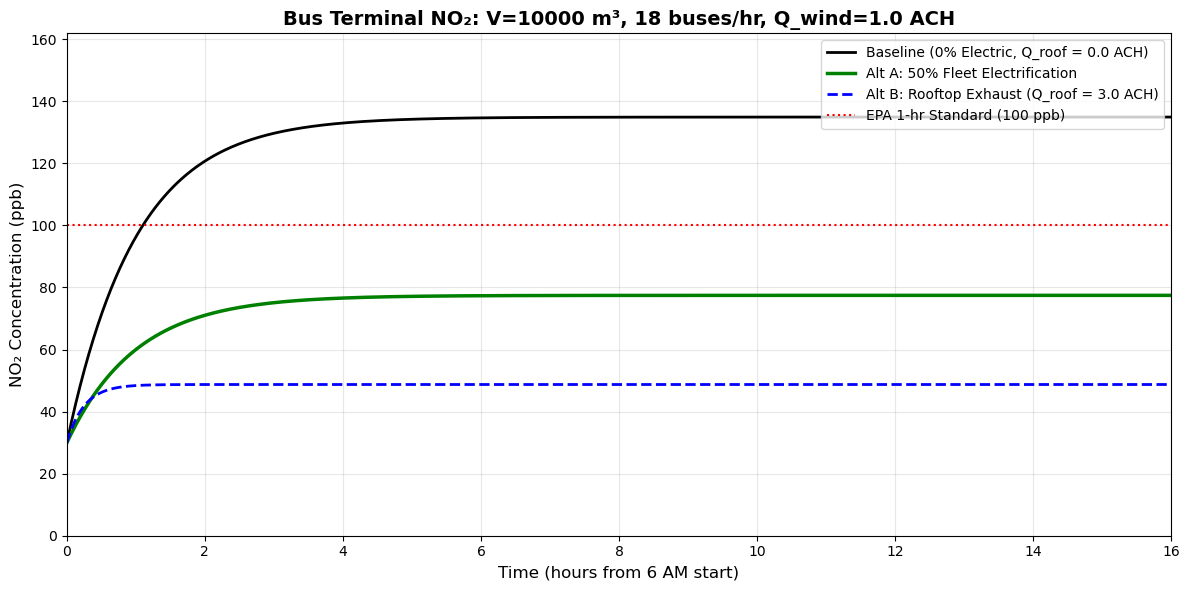

STEADY-STATE CONCENTRATION COMPARISON

Baseline (0% electric, 0 ACH exhaust):      135 ppb
Alt A (50% electric, 0 ACH exhaust):        77 ppb
Alt B (0% electric, 3.0 ACH exhaust):       49 ppb

EPA 1-hr Standard:                           100 ppb

REDUCTION FROM BASELINE:
  Alt A (50% Electrification): 43% reduction
  Alt B (3.0 ACH Exhaust Upgrade):     64% reduction

COMPLIANCE WITH EPA 1-HR STANDARD (100 ppb):
  Baseline: ⚠️ EXCEEDS standard (135 ppb)
  Alt A:    ✓ MEETS standard (77 ppb)
  Alt B:    ✓ MEETS standard (49 ppb)


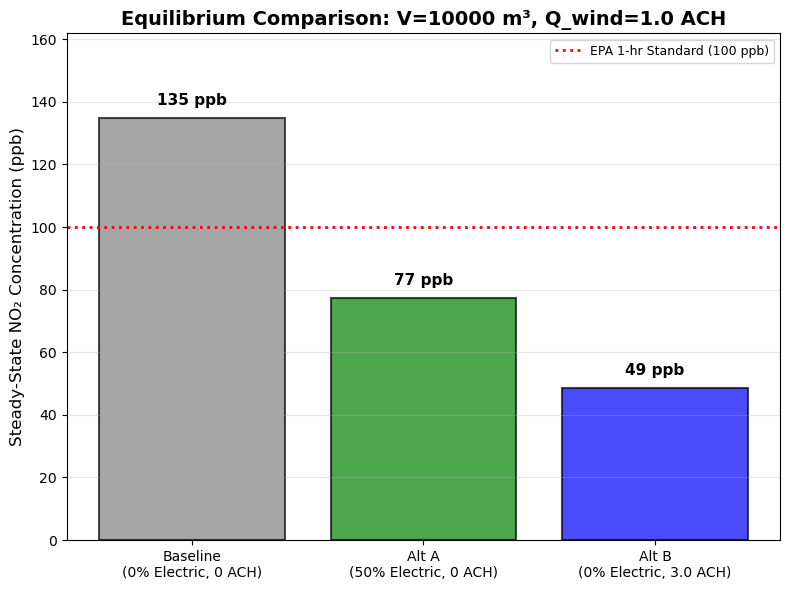


✓ Model run complete. Proceed to Cell 4 for MCDA matrix.


In [25]:
# ============================================
# CELL 3: RUN MODEL AND GENERATE VISUALIZATIONS
# ============================================
# Run this cell after adjusting inputs in Cell 2.
# This uses the current dropdown values to model all three scenarios.

import matplotlib.pyplot as plt

# --------------------------------------------------
# GET CURRENT VALUES FROM WIDGETS
# --------------------------------------------------
if V_dropdown.value == 'custom':
    V = V_custom.value
else:
    V = V_dropdown.value

if fleet_size_dropdown.value == 'custom':
    fleet_size = fleet_size_custom.value
else:
    fleet_size = fleet_size_dropdown.value
    
if buses_dropdown.value == 'custom':
    buses_per_hour = buses_custom.value
else:
    buses_per_hour = buses_dropdown.value
    
if idle_dropdown.value == 'custom':
    idle_time_min = idle_custom.value
else:
    idle_time_min = idle_dropdown.value
    
if Qwind_ach_dropdown.value == 'custom':
    Q_wind_ach = Qwind_ach_custom.value
else:
    Q_wind_ach = Qwind_ach_dropdown.value

# --------------------------------------------------
# COST PARAMETERS
# --------------------------------------------------
cost_per_electric_bus = 400000      # $400,000 per electric bus
cost_per_exhaust_m2 = 25            # $25 per m² for exhaust system

# --------------------------------------------------
# CALCULATE DERIVED PARAMETERS
# --------------------------------------------------
Q_wind = Q_wind_ach * V
Q_roof_base_m3hr = Q_roof_base * V
Q_roof_upgrade_m3hr = Q_roof_upgrade * V
terminal_area = V / 3.0  # Assume 3m ceiling height

avg_buses_idling = buses_per_hour * (idle_time_min / 60.0)
E_g_hr = avg_buses_idling * emission_factor
E_base = E_g_hr * 1e6 / 1.88

# Calculate costs
electrified_buses = fleet_size * 0.5
electrification_cost = electrified_buses * cost_per_electric_bus
exhaust_upgrade_cost = terminal_area * cost_per_exhaust_m2

# Time array
time_min = np.linspace(0, simulation_hours * 60, 1000)

# --------------------------------------------------
# RUN THREE SCENARIOS
# --------------------------------------------------

# Baseline: Diesel buses, no rooftop exhaust
C_base, C_ss_base, Q_total_base = terminal_no2_model(
    V=V, E_base=E_base, f_elec=f_elec_base, 
    Q_wind=Q_wind, Q_roof=Q_roof_base_m3hr,
    C_out=C_out, C0=C0, time_min=time_min
)

# Alternative A: 50% Electrification
C_elec, C_ss_elec, Q_total_elec = terminal_no2_model(
    V=V, E_base=E_base, f_elec=f_elec_altA,
    Q_wind=Q_wind, Q_roof=Q_roof_base_m3hr,
    C_out=C_out, C0=C0, time_min=time_min
)

# Alternative B: Rooftop exhaust upgrade
C_vent, C_ss_vent, Q_total_vent = terminal_no2_model(
    V=V, E_base=E_base, f_elec=f_elec_base,
    Q_wind=Q_wind, Q_roof=Q_roof_upgrade_m3hr,
    C_out=C_out, C0=C0, time_min=time_min
)

# Calculate reductions
reduction_A = ((C_ss_base - C_ss_elec) / C_ss_base) * 100
reduction_B = ((C_ss_base - C_ss_vent) / C_ss_base) * 100

# --------------------------------------------------
# TIME-SERIES PLOT
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(time_min / 60, C_base, 'k-', 
        label=f'Baseline (0% Electric, Q_roof = {Q_roof_base} ACH)', 
        linewidth=2)
ax.plot(time_min / 60, C_elec, 'g-', 
        label=f'Alt A: 50% Fleet Electrification', 
        linewidth=2.5)
ax.plot(time_min / 60, C_vent, 'b--', 
        label=f'Alt B: Rooftop Exhaust (Q_roof = {Q_roof_upgrade} ACH)', 
        linewidth=2)

ax.axhline(y=100, color='r', linestyle=':', 
           label='EPA 1-hr Standard (100 ppb)', 
           linewidth=1.5)

ax.set_xlabel('Time (hours from 6 AM start)', fontsize=12)
ax.set_ylabel('NO₂ Concentration (ppb)', fontsize=12)
ax.set_title(f'Bus Terminal NO₂: V={V:.0f} m³, {buses_per_hour:.0f} buses/hr, Q_wind={Q_wind_ach:.1f} ACH', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(0, simulation_hours)
ax.set_ylim(0, max(140, C_ss_base * 1.2))

plt.tight_layout()
plt.show()

# --------------------------------------------------
# PRINT STEADY-STATE COMPARISON
# --------------------------------------------------
print("="*70)
print("STEADY-STATE CONCENTRATION COMPARISON")
print("="*70)
print(f"\nBaseline (0% electric, 0 ACH exhaust):      {C_ss_base:.0f} ppb")
print(f"Alt A (50% electric, 0 ACH exhaust):        {C_ss_elec:.0f} ppb")
print(f"Alt B (0% electric, {Q_roof_upgrade} ACH exhaust):       {C_ss_vent:.0f} ppb")
print(f"\nEPA 1-hr Standard:                           100 ppb")
print("="*70)

print("\nREDUCTION FROM BASELINE:")
print(f"  Alt A (50% Electrification): {reduction_A:.0f}% reduction")
print(f"  Alt B ({Q_roof_upgrade} ACH Exhaust Upgrade):     {reduction_B:.0f}% reduction")
print("="*70)

print("\nCOMPLIANCE WITH EPA 1-HR STANDARD (100 ppb):")
print(f"  Baseline: {'⚠️ EXCEEDS' if C_ss_base > 100 else '✓ MEETS'} standard ({C_ss_base:.0f} ppb)")
print(f"  Alt A:    {'⚠️ EXCEEDS' if C_ss_elec > 100 else '✓ MEETS'} standard ({C_ss_elec:.0f} ppb)")
print(f"  Alt B:    {'⚠️ EXCEEDS' if C_ss_vent > 100 else '✓ MEETS'} standard ({C_ss_vent:.0f} ppb)")
print("="*70)

# --------------------------------------------------
# BAR CHART COMPARISON
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

scenarios = ['Baseline\n(0% Electric, 0 ACH)', 
             f'Alt A\n(50% Electric, 0 ACH)', 
             f'Alt B\n(0% Electric, {Q_roof_upgrade} ACH)']
concentrations = [C_ss_base, C_ss_elec, C_ss_vent]
colors = ['gray', 'green', 'blue']

bars = ax.bar(scenarios, concentrations, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

ax.axhline(y=100, color='r', linestyle=':', linewidth=2, label='EPA 1-hr Standard (100 ppb)')

for bar, conc in zip(bars, concentrations):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{conc:.0f} ppb', ha='center', va='bottom', 
            fontweight='bold', fontsize=11)

ax.set_ylabel('Steady-State NO₂ Concentration (ppb)', fontsize=12)
ax.set_title(f'Equilibrium Comparison: V={V:.0f} m³, Q_wind={Q_wind_ach:.1f} ACH', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, max(concentrations) * 1.2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Model run complete. Proceed to Cell 4 for MCDA matrix.")

In [26]:
# ============================================
# CELL 4: DYNAMIC MCDA MATRIX
# ============================================
# Run this cell after Cell 3 to generate the decision matrix.
# All scores update dynamically based on your inputs.

# --------------------------------------------------
# DYNAMIC TECHNICAL SCORING FUNCTION
# --------------------------------------------------
def get_technical_score(C_ss, reduction, other_reduction, meets_standard):
    """
    Technical score logic:
    - 5: Best reduction among alternatives AND meets standard
    - 4: Meets standard but not the best reduction
    - 3: Within 20% of standard (80-100 ppb) but doesn't meet
    - 2: Within 50% of standard (50-80 ppb equivalent)
    - 1: Far exceeds standard
    """
    if meets_standard:
        if reduction >= other_reduction:
            return 5
        else:
            return 4
    else:
        if C_ss <= 120:
            return 3
        elif C_ss <= 150:
            return 2
        else:
            return 1

# --------------------------------------------------
# DYNAMIC COST SCORING FUNCTION
# --------------------------------------------------
def get_cost_score(cost):
    """
    Cost score logic (lower cost = higher score):
    - 5: < $500K
    - 4: $500K - $2M
    - 3: $2M - $5M
    - 2: $5M - $10M
    - 1: > $10M
    """
    if cost < 500000:
        return 5
    elif cost < 2000000:
        return 4
    elif cost < 5000000:
        return 3
    elif cost < 10000000:
        return 2
    else:
        return 1

# --------------------------------------------------
# CALCULATE DYNAMIC SCORES
# --------------------------------------------------
best_reduction = max(reduction_A, reduction_B)

tech_score_base = 1
tech_score_A = get_technical_score(C_ss_elec, reduction_A, reduction_B, C_ss_elec <= 100)
tech_score_B = get_technical_score(C_ss_vent, reduction_B, reduction_A, C_ss_vent <= 100)

cost_score_base = 5
cost_score_A = get_cost_score(electrification_cost)
cost_score_B = get_cost_score(exhaust_upgrade_cost)

# Format cost strings for display
if electrification_cost >= 1e6:
    elec_cost_str = f"${electrification_cost/1e6:.1f}M"
else:
    elec_cost_str = f"${electrification_cost/1000:.0f}K"
    
if exhaust_upgrade_cost >= 1e6:
    exhaust_cost_str = f"${exhaust_upgrade_cost/1e6:.1f}M"
else:
    exhaust_cost_str = f"${exhaust_upgrade_cost/1000:.0f}K"

# --------------------------------------------------
# MCDA QUALITATIVE MATRIX
# --------------------------------------------------
print("\n" + "="*90)
print("MULTI-CRITERIA DECISION ANALYSIS (MCDA) MATRIX")
print("="*90)

print(f"{'Criterion':<35} {'Weight':<8} {'Baseline':<15} {'Alt A':<15} {'Alt B':<15}")
print("-"*90)

# Technical Effectiveness
print(f"{'Technical: Steady-State NO₂':<35} {'0.30':<8} {f'{C_ss_base:.0f} ppb':<15} {f'{C_ss_elec:.0f} ppb':<15} {f'{C_ss_vent:.0f} ppb':<15}")
print(f"{'  → Reduction from baseline':<35} {'':<8} {'--':<15} {f'{reduction_A:.0f}%':<15} {f'{reduction_B:.0f}%':<15}")
meets_base = "NO" if C_ss_base > 100 else "YES"
meets_elec = "YES" if C_ss_elec <= 100 else "NO"
meets_vent = "YES" if C_ss_vent <= 100 else "NO"
print(f"{'  → Meets EPA 100 ppb?':<35} {'':<8} {meets_base:<15} {meets_elec:<15} {meets_vent:<15}")

print("-"*90)

# Cost & Practicality
print(f"{'Cost: Capital Investment':<35} {'0.25':<8} {'N/A':<15} {elec_cost_str:<15} {exhaust_cost_str:<15}")
print(f"{'Cost: Operating (Annual)':<35} {'0.10':<8} {'Diesel':<15} {'Electricity':<15} {'Energy + Maint':<15}")
print(f"{'  → Buses electrified':<35} {'':<8} {'0':<15} {f'{electrified_buses:.0f} buses':<15} {'0':<15}")
print(f"{'  → Exhaust fans added':<35} {'':<8} {'0':<15} {'0':<15} {f'{Q_roof_upgrade} ACH':<15}")

print("-"*90)

# Public Health & Safety
print(f"{'Health: Worker Exposure':<35} {'0.15':<8} {'High':<15} {'Reduced':<15} {'Reduced':<15}")
print(f"{'Health: Commuter Exposure':<35} {'0.05':<8} {'Moderate':<15} {'Reduced':<15} {'Reduced':<15}")
print(f"{'  → Co-Benefits':<35} {'':<8} {'None':<15} {'No PM2.5/VOCs':<15} {'Dilutes all':<15}")

print("-"*90)

# Environmental Considerations
print(f"{'Environmental: GHG Emissions':<35} {'0.10':<8} {'High':<15} {'Lower':<15} {'Higher energy':<15}")
print(f"{'Environmental: Noise Pollution':<35} {'0.05':<8} {'High':<15} {'Near-silent':<15} {'Fan noise':<15}")

print("="*90)

# --------------------------------------------------
# WEIGHTED SCORING MATRIX
# --------------------------------------------------
print("\n" + "="*90)
print("WEIGHTED SCORING MATRIX (1-5 Scale, 5 = Best)")
print("="*90)

# Dynamic raw scores
baseline_raw = [tech_score_base, cost_score_base, 1, 2]
altA_raw = [tech_score_A, cost_score_A, 5, 4]
altB_raw = [tech_score_B, cost_score_B, 3, 3]

# Weights
criteria = ['Technical Effectiveness', 'Cost & Practicality', 'Public Health', 'Environmental']
weights = [0.30, 0.35, 0.20, 0.15]

# Calculate weighted scores
baseline_weighted = [raw * w for raw, w in zip(baseline_raw, weights)]
altA_weighted = [raw * w for raw, w in zip(altA_raw, weights)]
altB_weighted = [raw * w for raw, w in zip(altB_raw, weights)]

# Print table
print(f"{'Criterion':<30} {'Weight':<10} {'Base':<8} {'Alt A':<8} {'Alt B':<8} {'Wt Base':<10} {'Wt Alt A':<10} {'Wt Alt B':<10}")
print("-"*95)

for i in range(len(criteria)):
    print(f"{criteria[i]:<30} {weights[i]:<10.2f} {baseline_raw[i]:<8} {altA_raw[i]:<8} {altB_raw[i]:<8} "
          f"{baseline_weighted[i]:<10.2f} {altA_weighted[i]:<10.2f} {altB_weighted[i]:<10.2f}")

print("-"*95)
total_base = sum(baseline_weighted)
total_A = sum(altA_weighted)
total_B = sum(altB_weighted)
print(f"{'TOTAL SCORE':<30} {'':<10} {'':<8} {'':<8} {'':<8} "
      f"{total_base:<10.2f} {total_A:<10.2f} {total_B:<10.2f}")
print("="*95)

# --------------------------------------------------
# DYNAMIC INTERPRETATION
# --------------------------------------------------
print("\nINTERPRETATION (Based on Current Inputs):")
print("-"*50)

print(f"\nTechnical Scores:")
print(f"  Baseline: {tech_score_base} (fails standard)")
print(f"  Alt A: {tech_score_A} ({reduction_A:.0f}% reduction, {'meets' if C_ss_elec <= 100 else 'fails'} standard)")
print(f"  Alt B: {tech_score_B} ({reduction_B:.0f}% reduction, {'meets' if C_ss_vent <= 100 else 'fails'} standard)")
if tech_score_A == 5:
    print(f"  → Alt A gets 5 for best reduction")
elif tech_score_B == 5:
    print(f"  → Alt B gets 5 for best reduction")

print(f"\nCost Scores:")
print(f"  Baseline: {cost_score_base} (no implementation cost)")
print(f"  Alt A: {cost_score_A} (${electrification_cost:,.0f} for {electrified_buses:.0f} electric buses)")
print(f"  Alt B: {cost_score_B} (${exhaust_upgrade_cost:,.0f} for {terminal_area:.0f} m² exhaust system)")

print(f"\nOVERALL RESULT:")
if total_A > total_B:
    print(f"✓ Alternative A (50% Electrification) scores higher ({total_A:.2f} vs {total_B:.2f}).")
    print(f"  The health and environmental co-benefits outweigh the higher capital cost.")
elif total_B > total_A:
    print(f"✓ Alternative B (Rooftop Exhaust) scores higher ({total_B:.2f} vs {total_A:.2f}).")
    print(f"  The lower capital cost and quick implementation outweigh the health co-benefits.")
else:
    print(f"✓ Alternatives A and B tie ({total_A:.2f}).")
    print(f"  The decision should consider secondary factors like implementation timeline.")

print("\nNOTE: All scores and costs update dynamically based on your inputs.")
print("Weights can be adjusted to reflect different stakeholder priorities.")
print("="*90)


MULTI-CRITERIA DECISION ANALYSIS (MCDA) MATRIX
Criterion                           Weight   Baseline        Alt A           Alt B          
------------------------------------------------------------------------------------------
Technical: Steady-State NO₂         0.30     135 ppb         77 ppb          49 ppb         
  → Reduction from baseline                  --              43%             64%            
  → Meets EPA 100 ppb?                       NO              YES             YES            
------------------------------------------------------------------------------------------
Cost: Capital Investment            0.25     N/A             $8.0M           $83K           
Cost: Operating (Annual)            0.10     Diesel          Electricity     Energy + Maint 
  → Buses electrified                        0               20 buses        0              
  → Exhaust fans added                       0               0               3.0 ACH        
--------------------------